# 03 — Feature Engineering and Selection

This notebook constructs and selects the predictor sets used for COPD exacerbation forecasting.

The workflow includes:

- creation of calendar and cyclical seasonal features;
- construction of two alternative environmental-exposure representations;
- temporal separation of the development period (2010–2022) and final test year (2023);
- preliminary redundancy filtering based on Pearson correlation;
- feature scaling using the development data;
- feature selection using minimum redundancy maximum relevance (mRMR);
- temporal block bootstrap to assess selection stability.

Two alternative predictor subsets are evaluated:

- **Subset A:** immediate and accumulated environmental exposures;
- **Subset B:** individual daily environmental lags.

In [21]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import json

from copd_forecasting.config import (
    PROCESSED_DATA_FILE,
    DATE_COLUMN,
    TEST_YEAR,
    FEATURE_SELECTION_FILE,
)

from copd_forecasting.features import (
    TEMPORAL_COLS,
    add_temporal_features,
    create_binary_target,
    build_subset_a,
    build_subset_b,
)

from copd_forecasting.selection import (
    prepare_feature_subset,
    temporal_block_bootstrap_mrmr,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Feature engineering

The cleaned dataset is enriched with calendar and cyclical seasonal features before constructing the two alternative environmental-exposure representations used in the study.

In [2]:
df = pd.read_excel(
    PROCESSED_DATA_FILE,
    parse_dates=[DATE_COLUMN],
)

df = (
    df
    .sort_values(DATE_COLUMN)
    .reset_index(drop=True)
)

print(
    f"Dataset shape: "
    f"{df.shape[0]:,} rows × "
    f"{df.shape[1]} columns"
)

print(
    f"Date range: "
    f"{df[DATE_COLUMN].min().date()} → "
    f"{df[DATE_COLUMN].max().date()}"
)

Dataset shape: 5,106 rows × 187 columns
Date range: 2010-01-08 → 2023-12-31


In [3]:
df = add_temporal_features(df)

y = create_binary_target(df)

subset_a = build_subset_a(df)
subset_b = build_subset_b(df)

print(
    f"Subset A: "
    f"{subset_a.shape[1]} predictors"
)

print(
    f"Subset B: "
    f"{subset_b.shape[1]} predictors"
)

print(
    f"Target positive rate: "
    f"{y.mean():.3f}"
)

Subset A: 48 predictors
Subset B: 155 predictors
Target positive rate: 0.548


## 2. Temporal development–test split

The final year of the time series (2023) is reserved as an independent test set.

All feature engineering decisions, redundancy filtering and feature selection are performed using the development period (2010–2022), preventing direct use of the final test year during model development.

In [4]:
dates = df[DATE_COLUMN]

development_mask = (
    dates.dt.year < TEST_YEAR
).to_numpy()

test_mask = (
    dates.dt.year == TEST_YEAR
).to_numpy()

y_development = y[
    development_mask
].to_numpy()

y_test = y[
    test_mask
].to_numpy()

print(
    f"Development (2010–2022): "
    f"{development_mask.sum():,} samples"
)

print(
    f"Test (2023): "
    f"{test_mask.sum():,} samples"
)

print(
    f"Positive rate — development: "
    f"{y_development.mean():.3f}"
)

print(
    f"Positive rate — test: "
    f"{y_test.mean():.3f}"
)

Development (2010–2022): 4,741 samples
Test (2023): 365 samples
Positive rate — development: 0.548
Positive rate — test: 0.553


## 3. Preliminary redundancy filtering

Highly redundant predictors are removed before mRMR feature selection.

Absolute Pearson correlation is calculated using only the development period. For predictor pairs with \(|r| > 0.8\), the variable with the greater mean absolute correlation with the remaining predictors is removed.

The same threshold is applied independently to Subsets A and B.

In [5]:
from copd_forecasting.selection import (
    prepare_feature_subset,
)

In [6]:
prepared_a = prepare_feature_subset(
    subset_a,
    development_mask,
    test_mask,
    correlation_threshold=0.8,
)

prepared_b = prepare_feature_subset(
    subset_b,
    development_mask,
    test_mask,
    correlation_threshold=0.8,
)

print(
    f"Subset A: "
    f"{subset_a.shape[1]} → "
    f"{len(prepared_a['features'])} predictors"
)

print(
    f"Subset B: "
    f"{subset_b.shape[1]} → "
    f"{len(prepared_b['features'])} predictors"
)

Subset A: 48 → 24 predictors
Subset B: 155 → 76 predictors


In [7]:
print("Subset A removed features:")
print(
    "\n".join(
        prepared_a[
            "removed_features"
        ]
    )
)

Subset A removed features:
CO_ACUM_0_3
NO2_ACUM_0_7
NO_ACUM_0_7
O3_ACUM_0_3
O3_ACUM_0_7
PM10_ACUM_0_3
PM2p5_ACUM_0_3
PM2p5_IMM
hume_max_ACUM_0_3
pres_max_ACUM_0_3
pres_max_IMM
pres_min_ACUM_0_3
pres_min_ACUM_0_7
sol_24_ACUM_0_3
sol_24_ACUM_0_7
temp_max_ACUM_0_3
temp_max_ACUM_0_7
temp_max_IMM
temp_min_ACUM_0_3
temp_min_ACUM_0_7
temp_sens_ACUM_0_3
temp_sens_ACUM_0_7
temp_sens_IMM
vel_max_ACUM_0_3


In [8]:
print("Subset B removed features:")
print(
    "\n".join(
        prepared_b[
            "removed_features"
        ]
    )
)

Subset B removed features:
O3_LAG-1
O3_LAG-3
O3_LAG-4
O3_LAG-5
O3_LAG-6
PM2p5_LAG-1
PM2p5_LAG-2
PM2p5_LAG-3
PM2p5_LAG-4
PM2p5_LAG-5
PM2p5_LAG-6
PM2p5_LAG-7
PM2p5_LAG0
hume_med_LAG-1
hume_med_LAG-2
hume_med_LAG-3
hume_med_LAG-4
hume_med_LAG-5
hume_med_LAG-6
hume_med_LAG-7
hume_med_LAG0
pres_max_LAG-1
pres_max_LAG-2
pres_max_LAG-3
pres_max_LAG-4
pres_max_LAG-6
pres_max_LAG-7
pres_max_LAG0
pres_med_LAG-1
pres_med_LAG-2
pres_med_LAG-3
pres_med_LAG-4
pres_med_LAG-5
pres_med_LAG-6
pres_med_LAG0
pres_min_LAG-1
pres_min_LAG-3
pres_min_LAG-4
pres_min_LAG-5
pres_min_LAG-6
pres_min_LAG-7
temp_max_LAG-1
temp_max_LAG-2
temp_max_LAG-3
temp_max_LAG-4
temp_max_LAG-5
temp_max_LAG-6
temp_max_LAG-7
temp_max_LAG0
temp_med_LAG-1
temp_med_LAG-2
temp_med_LAG-3
temp_med_LAG-4
temp_med_LAG-5
temp_med_LAG-6
temp_med_LAG-7
temp_med_LAG0
temp_min_LAG-1
temp_min_LAG-2
temp_min_LAG-3
temp_min_LAG-4
temp_min_LAG-5
temp_min_LAG-6
temp_sens_LAG-1
temp_sens_LAG-2
temp_sens_LAG-3
temp_sens_LAG-4
temp_sens_LAG-5
temp_sen

## 4. mRMR selection with temporal block bootstrap

After redundancy filtering, feature selection is performed using minimum redundancy maximum relevance (mRMR).

Predictor relevance is estimated through mutual information with the binary target, while redundancy is quantified using mutual information between predictors.

To assess selection stability while partially preserving temporal dependence, the development series is resampled using contiguous seven-day blocks. A predictor is considered selected within a bootstrap replicate when its mRMR score is positive.

The final selection threshold is not predefined. Instead, predictors are retained when their bootstrap selection frequency exceeds the mean frequency observed across all candidate predictors.

In [10]:
mrmr_a = temporal_block_bootstrap_mrmr(
    X=prepared_a["X_development"],
    y=y_development,
    feature_names=prepared_a["features"],
    n_bootstrap=1000,
    block_size=7,
    random_state=42,
)

Computing predictor mutual-information matrix...
Bootstrap replicate 100/1000
Bootstrap replicate 200/1000
Bootstrap replicate 300/1000
Bootstrap replicate 400/1000
Bootstrap replicate 500/1000
Bootstrap replicate 600/1000
Bootstrap replicate 700/1000
Bootstrap replicate 800/1000
Bootstrap replicate 900/1000
Bootstrap replicate 1000/1000


In [11]:
print(
    f"Subset A selection threshold: "
    f"{mrmr_a['threshold'] * 100:.2f}%"
)

print(
    f"Selected features: "
    f"{len(mrmr_a['selected_features'])}"
)

mrmr_a["selected_features"]

Subset A selection threshold: 16.87%
Selected features: 6


['PM10_ACUM_0_7',
 'NO2_ACUM_0_3',
 'O3_IMM',
 'pres_max_ACUM_0_7',
 'dia_semana',
 'estac_sin']

In [12]:
mrmr_b = temporal_block_bootstrap_mrmr(
    X=prepared_b["X_development"],
    y=y_development,
    feature_names=prepared_b["features"],
    n_bootstrap=1000,
    block_size=7,
    random_state=42,
)

Computing predictor mutual-information matrix...
Bootstrap replicate 100/1000
Bootstrap replicate 200/1000
Bootstrap replicate 300/1000
Bootstrap replicate 400/1000
Bootstrap replicate 500/1000
Bootstrap replicate 600/1000
Bootstrap replicate 700/1000
Bootstrap replicate 800/1000
Bootstrap replicate 900/1000
Bootstrap replicate 1000/1000


In [13]:
print(
    f"Subset B selection threshold: "
    f"{mrmr_b['threshold'] * 100:.2f}%"
)

print(
    f"Selected features: "
    f"{len(mrmr_b['selected_features'])}"
)

mrmr_b["selected_features"]

Subset B selection threshold: 13.22%
Selected features: 24


['PM10_LAG0',
 'PM10_LAG-3',
 'PM10_LAG-7',
 'NO2_LAG0',
 'NO2_LAG-1',
 'NO2_LAG-2',
 'NO2_LAG-3',
 'NO2_LAG-4',
 'NO2_LAG-5',
 'NO2_LAG-6',
 'NO2_LAG-7',
 'O3_LAG-2',
 'O3_LAG-7',
 'pres_min_LAG0',
 'pres_med_LAG-7',
 'prec_24_LAG0',
 'prec_24_LAG-1',
 'prec_24_LAG-2',
 'prec_24_LAG-3',
 'prec_24_LAG-4',
 'prec_24_LAG-5',
 'prec_24_LAG-6',
 'prec_24_LAG-7',
 'estac_sin']

In [14]:
def selection_frequency_table(
    result: dict,
) -> pd.DataFrame:
    """Create a ranked table of bootstrap selection frequencies."""

    table = pd.DataFrame(
        {
            "Feature": result["feature_names"],
            "Frequency": result["frequencies"],
        }
    )

    table["Frequency (%)"] = (
        table["Frequency"] * 100
    )

    table["Selected"] = (
        table["Frequency"]
        > result["threshold"]
    )

    return (
        table
        .sort_values(
            "Frequency",
            ascending=False,
        )
        .reset_index(drop=True)
    )

In [15]:
frequency_a = selection_frequency_table(
    mrmr_a
)

frequency_b = selection_frequency_table(
    mrmr_b
)

frequency_a

,Feature,Frequency,Frequency (%),Selected
0,PM10_ACUM_0_7,0.857,85.7,True
1,pres_max_ACUM_0_7,0.787,78.7,True
2,NO2_ACUM_0_3,0.582,58.2,True
3,O3_IMM,0.431,43.1,True
4,dia_semana,0.410,41.0,True
5,estac_sin,0.307,30.7,True
6,NO_ACUM_0_3,0.145,14.5,False
7,PM2p5_ACUM_0_7,0.142,14.2,False
8,prec_24_IMM,0.135,13.5,False
9,pres_min_IMM,0.133,13.3,False


In [16]:
frequency_b

,Feature,Frequency,Frequency (%),Selected
0,estac_sin,0.998,99.8,True
1,pres_med_LAG-7,0.924,92.4,True
2,NO2_LAG0,0.540,54.0,True
3,NO2_LAG-2,0.523,52.3,True
4,NO2_LAG-7,0.504,50.4,True
...,...,...,...,...
71,hume_max_LAG-3,0.000,0.0,False
72,hume_max_LAG-6,0.000,0.0,False
73,hume_max_LAG-5,0.000,0.0,False
74,hume_max_LAG-4,0.000,0.0,False


## 5. Bootstrap selection stability

Selection frequencies quantify how consistently each predictor is retained across temporal bootstrap replicates.

The dashed line represents the subset-specific mean selection frequency used as the final threshold.

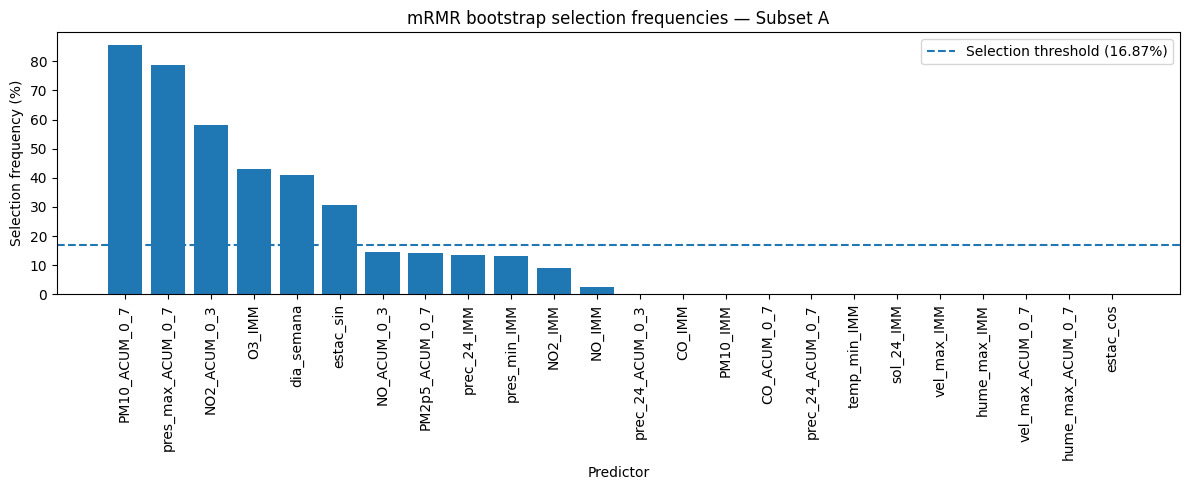

In [17]:
fig, ax = plt.subplots(
    figsize=(12, 5)
)

ax.bar(
    frequency_a["Feature"],
    frequency_a["Frequency (%)"],
)

ax.axhline(
    mrmr_a["threshold"] * 100,
    linestyle="--",
    label=(
        f"Selection threshold "
        f"({mrmr_a['threshold'] * 100:.2f}%)"
    ),
)

ax.set_title(
    "mRMR bootstrap selection frequencies — Subset A"
)

ax.set_xlabel("Predictor")
ax.set_ylabel("Selection frequency (%)")

ax.tick_params(
    axis="x",
    rotation=90,
)

ax.legend()

plt.tight_layout()
plt.show()

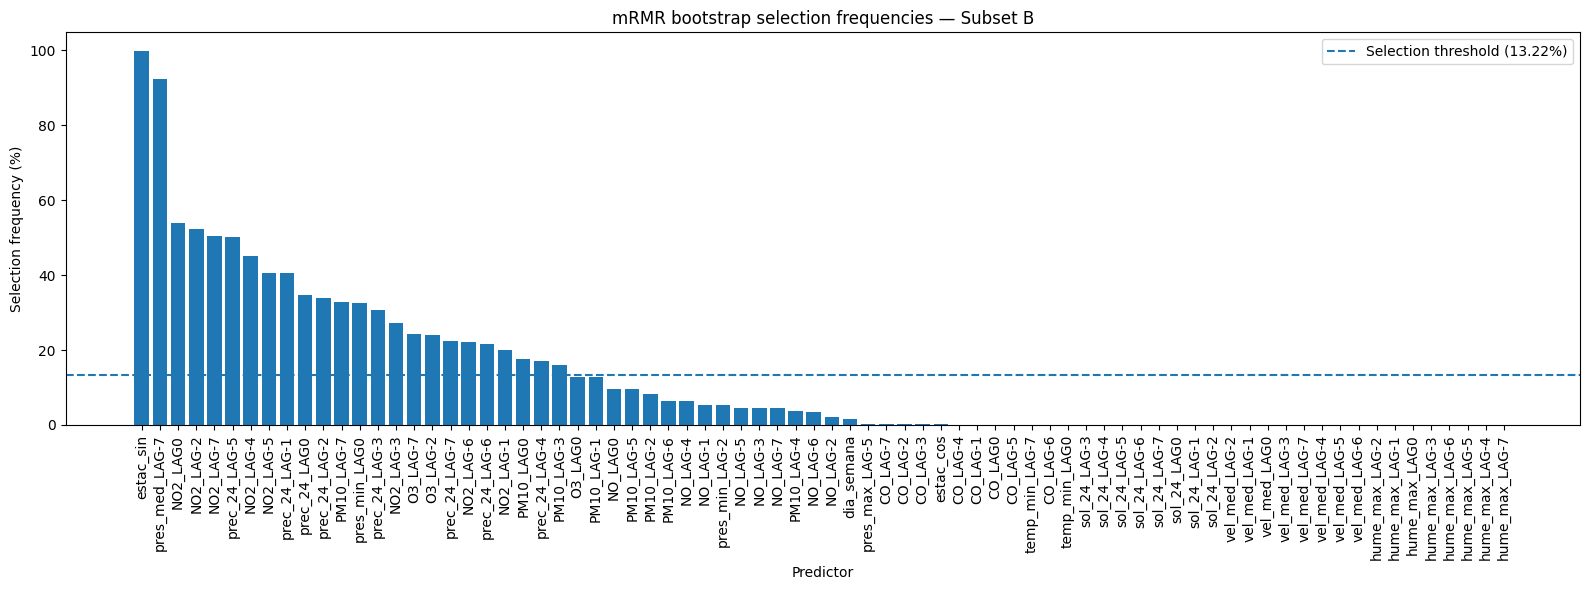

In [18]:
fig, ax = plt.subplots(
    figsize=(16, 6)
)

ax.bar(
    frequency_b["Feature"],
    frequency_b["Frequency (%)"],
)

ax.axhline(
    mrmr_b["threshold"] * 100,
    linestyle="--",
    label=(
        f"Selection threshold "
        f"({mrmr_b['threshold'] * 100:.2f}%)"
    ),
)

ax.set_title(
    "mRMR bootstrap selection frequencies — Subset B"
)

ax.set_xlabel("Predictor")
ax.set_ylabel("Selection frequency (%)")

ax.tick_params(
    axis="x",
    rotation=90,
)

ax.legend()

plt.tight_layout()
plt.show()

In [19]:
print(
    f"Subset A: "
    f"{len(prepared_a['features'])} candidates → "
    f"{len(mrmr_a['selected_features'])} selected"
)

print(
    f"Subset B: "
    f"{len(prepared_b['features'])} candidates → "
    f"{len(mrmr_b['selected_features'])} selected"
)

Subset A: 24 candidates → 6 selected
Subset B: 76 candidates → 24 selected


## 6. Save feature-selection results

The final mRMR selections are stored as a JSON artifact so that subsequent modelling stages can reproduce the selected predictor sets without rerunning the computationally expensive temporal bootstrap procedure.

The file contains the final selected predictors, the bootstrap selection threshold and the selection frequency of every candidate predictor.

In [22]:
selection_results = {
    "subset_a": {
        "initial_features": subset_a.shape[1],
        "after_correlation_filter": len(
            prepared_a["features"]
        ),
        "selection_threshold": float(
            mrmr_a["threshold"]
        ),
        "selected_features": list(
            mrmr_a["selected_features"]
        ),
        "selection_frequencies": {
            feature: float(frequency)
            for feature, frequency in zip(
                mrmr_a["feature_names"],
                mrmr_a["frequencies"],
            )
        },
    },
    "subset_b": {
        "initial_features": subset_b.shape[1],
        "after_correlation_filter": len(
            prepared_b["features"]
        ),
        "selection_threshold": float(
            mrmr_b["threshold"]
        ),
        "selected_features": list(
            mrmr_b["selected_features"]
        ),
        "selection_frequencies": {
            feature: float(frequency)
            for feature, frequency in zip(
                mrmr_b["feature_names"],
                mrmr_b["frequencies"],
            )
        },
    },
}

In [23]:
FEATURE_SELECTION_FILE.parent.mkdir(
    parents=True,
    exist_ok=True,
)

with open(
    FEATURE_SELECTION_FILE,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        selection_results,
        file,
        indent=4,
        ensure_ascii=False,
    )

print(
    f"✓ Feature-selection results saved to: "
    f"{FEATURE_SELECTION_FILE}"
)

✓ Feature-selection results saved to: C:\Users\migue\Desktop\Healthcare-AI\copd-exacerbation-forecasting\reports\feature_selection_results.json


In [24]:
with open(
    FEATURE_SELECTION_FILE,
    "r",
    encoding="utf-8",
) as file:
    saved_selection = json.load(file)

print(
    "Subset A:",
    len(
        saved_selection[
            "subset_a"
        ]["selected_features"]
    ),
    "selected features",
)

print(
    "Subset B:",
    len(
        saved_selection[
            "subset_b"
        ]["selected_features"]
    ),
    "selected features",
)

Subset A: 6 selected features
Subset B: 24 selected features


## 7. Feature-selection summary

Two alternative representations of environmental exposure were constructed and evaluated.

- **Subset A** started with 48 predictors based on immediate and accumulated exposures. Correlation filtering reduced this set to 24 predictors, and temporal-bootstrap mRMR finally retained 6.
- **Subset B** started with 155 predictors representing individual daily lags. Correlation filtering reduced this set to 76 predictors, and temporal-bootstrap mRMR retained 24.

The selected features are stored for reuse during temporal model validation and final model evaluation.

Feature engineering, correlation filtering, scaling and mRMR selection were performed without using the independent 2023 test set.